In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest

from ctg_viz import CTGViz
from ctg_viz.plots.histograms import plot_histogram
from ctg_viz.plots.barplots import plot_barplot
from ctg_viz.plots.boxplots import plot_boxplot
from ctg_viz.plots.dotplots import plot_dotplot

## Preprocessing

### Análisis exploratorio

In [2]:
df = pd.read_csv('../../datasets/CTG.csv')

In [3]:
df.head()

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Variab10.txt,12/1/1996,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,Fmcs_1.txt,5/3/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,5/3/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,5/3/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,5/3/1996,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0


In [4]:
df['C'].value_counts()

C
0.0    2073
1.0      53
Name: count, dtype: int64

In [5]:
#Columnas no significantes
df=df.drop(["FileName","Date","SegFile","b","e"],axis=1)
df.shape

(2129, 35)

In [6]:
#Verificando completitud
viz = CTGViz(df)
viz.check_data_completeness_dafneelizabethzepedagonzalez()

In [7]:
#Eliminando columnas con porctenaje de missings mayoe o iguales a 20%
for col in df.columns:
    if df[col].isnull().sum()/df.size >= 20:
        df = df.drop(col, axis=1)

In [8]:
#Clasificaion de variables continuas y discretas
varc, vard = viz.vars_categorization()

In [9]:
varc

['LBE',
 'LB',
 'AC',
 'FM',
 'UC',
 'ASTV',
 'MSTV',
 'ALTV',
 'MLTV',
 'DL',
 'Width',
 'Min',
 'Max',
 'Nmax',
 'Mode',
 'Mean',
 'Median',
 'Variance']

In [10]:
vard

['DS',
 'DP',
 'DR',
 'Nzeros',
 'Tendency',
 'A',
 'B',
 'C',
 'D',
 'E',
 'AD',
 'DE',
 'LD',
 'FS',
 'SUSP',
 'CLASS',
 'NSP']

## Analisis de Datos

### Imputación de datos faltantes

In [11]:
#Imputación de datos faltantes
#Variables DISCRETAS
most_frec_imputer = SimpleImputer(strategy='most_frequent')

df[vard] = most_frec_imputer.fit_transform(df[vard])

In [25]:
#variables CONTINUAS usando KNN Imputer
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[varc])

imputer = KNNImputer(n_neighbors=5, weights='distance')

df_imputed_scaled = imputer.fit_transform(df_scaled)

df_imputed = scaler.inverse_transform(df_imputed_scaled)
df_imputed = pd.DataFrame(df_imputed, columns=varc)

df[varc] = df_imputed[varc]

In [31]:
df['LB'].isnull().sum()

np.int64(0)

In [29]:
#Validación de imputación
viz = CTGViz(df)
viz.check_data_completeness_dafneelizabethzepedagonzalez()

### Imputación de Outliers

array([[<Axes: title={'center': 'LBE'}>, <Axes: title={'center': 'LB'}>,
        <Axes: title={'center': 'AC'}>, <Axes: title={'center': 'FM'}>],
       [<Axes: title={'center': 'UC'}>, <Axes: title={'center': 'ASTV'}>,
        <Axes: title={'center': 'MSTV'}>,
        <Axes: title={'center': 'ALTV'}>],
       [<Axes: title={'center': 'MLTV'}>, <Axes: title={'center': 'DL'}>,
        <Axes: title={'center': 'Width'}>,
        <Axes: title={'center': 'Min'}>],
       [<Axes: title={'center': 'Max'}>,
        <Axes: title={'center': 'Nmax'}>,
        <Axes: title={'center': 'Mode'}>,
        <Axes: title={'center': 'Mean'}>],
       [<Axes: title={'center': 'Median'}>,
        <Axes: title={'center': 'Variance'}>, <Axes: >, <Axes: >]],
      dtype=object)

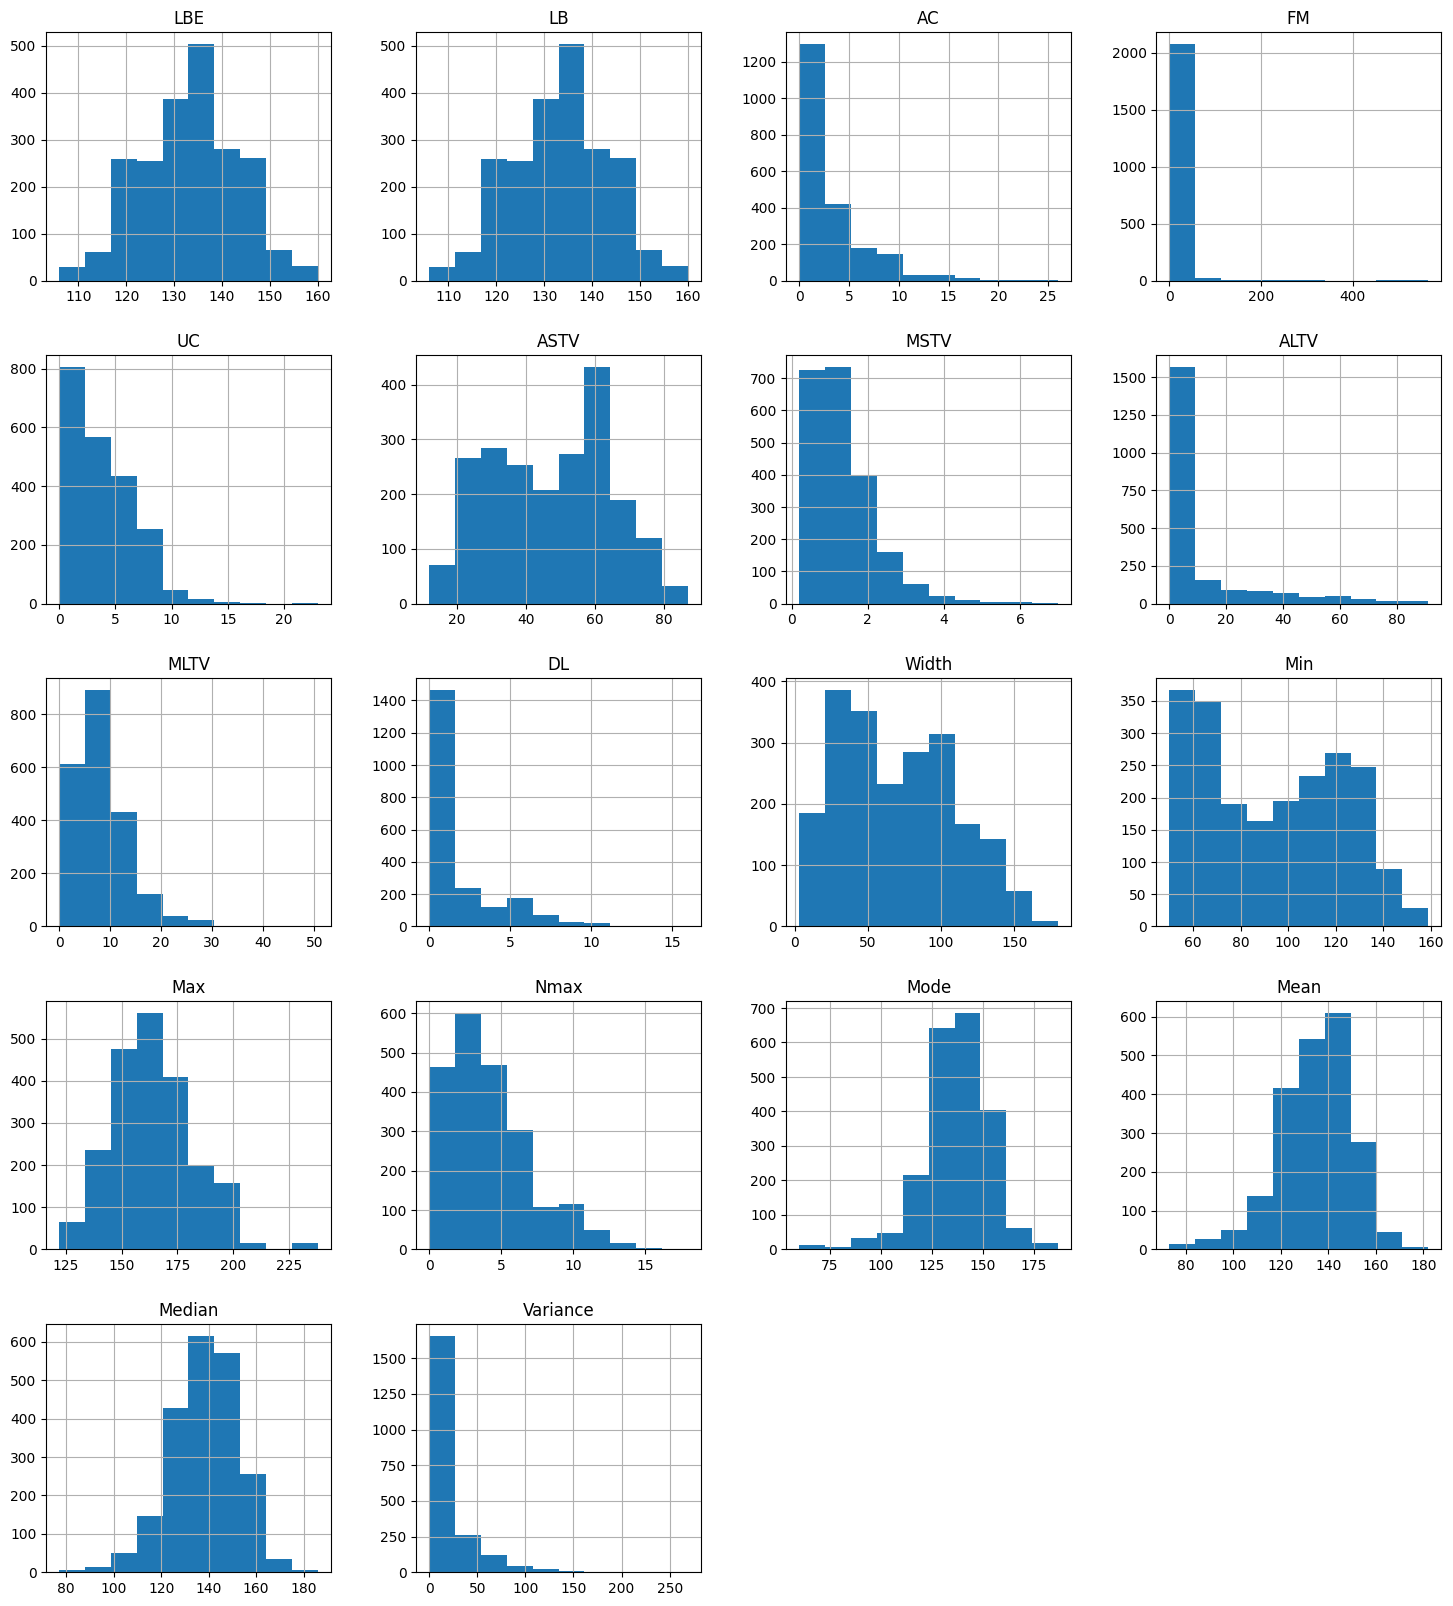

In [14]:
df[varc].hist(figsize=(18, 20))

array([[<Axes: title={'center': 'LBE'}>, <Axes: title={'center': 'LB'}>,
        <Axes: title={'center': 'AC'}>, <Axes: title={'center': 'FM'}>],
       [<Axes: title={'center': 'UC'}>, <Axes: title={'center': 'ASTV'}>,
        <Axes: title={'center': 'MSTV'}>,
        <Axes: title={'center': 'ALTV'}>],
       [<Axes: title={'center': 'MLTV'}>, <Axes: title={'center': 'DL'}>,
        <Axes: title={'center': 'Width'}>,
        <Axes: title={'center': 'Min'}>],
       [<Axes: title={'center': 'Max'}>,
        <Axes: title={'center': 'Nmax'}>,
        <Axes: title={'center': 'Mode'}>,
        <Axes: title={'center': 'Mean'}>],
       [<Axes: title={'center': 'Median'}>,
        <Axes: title={'center': 'Variance'}>, <Axes: >, <Axes: >]],
      dtype=object)

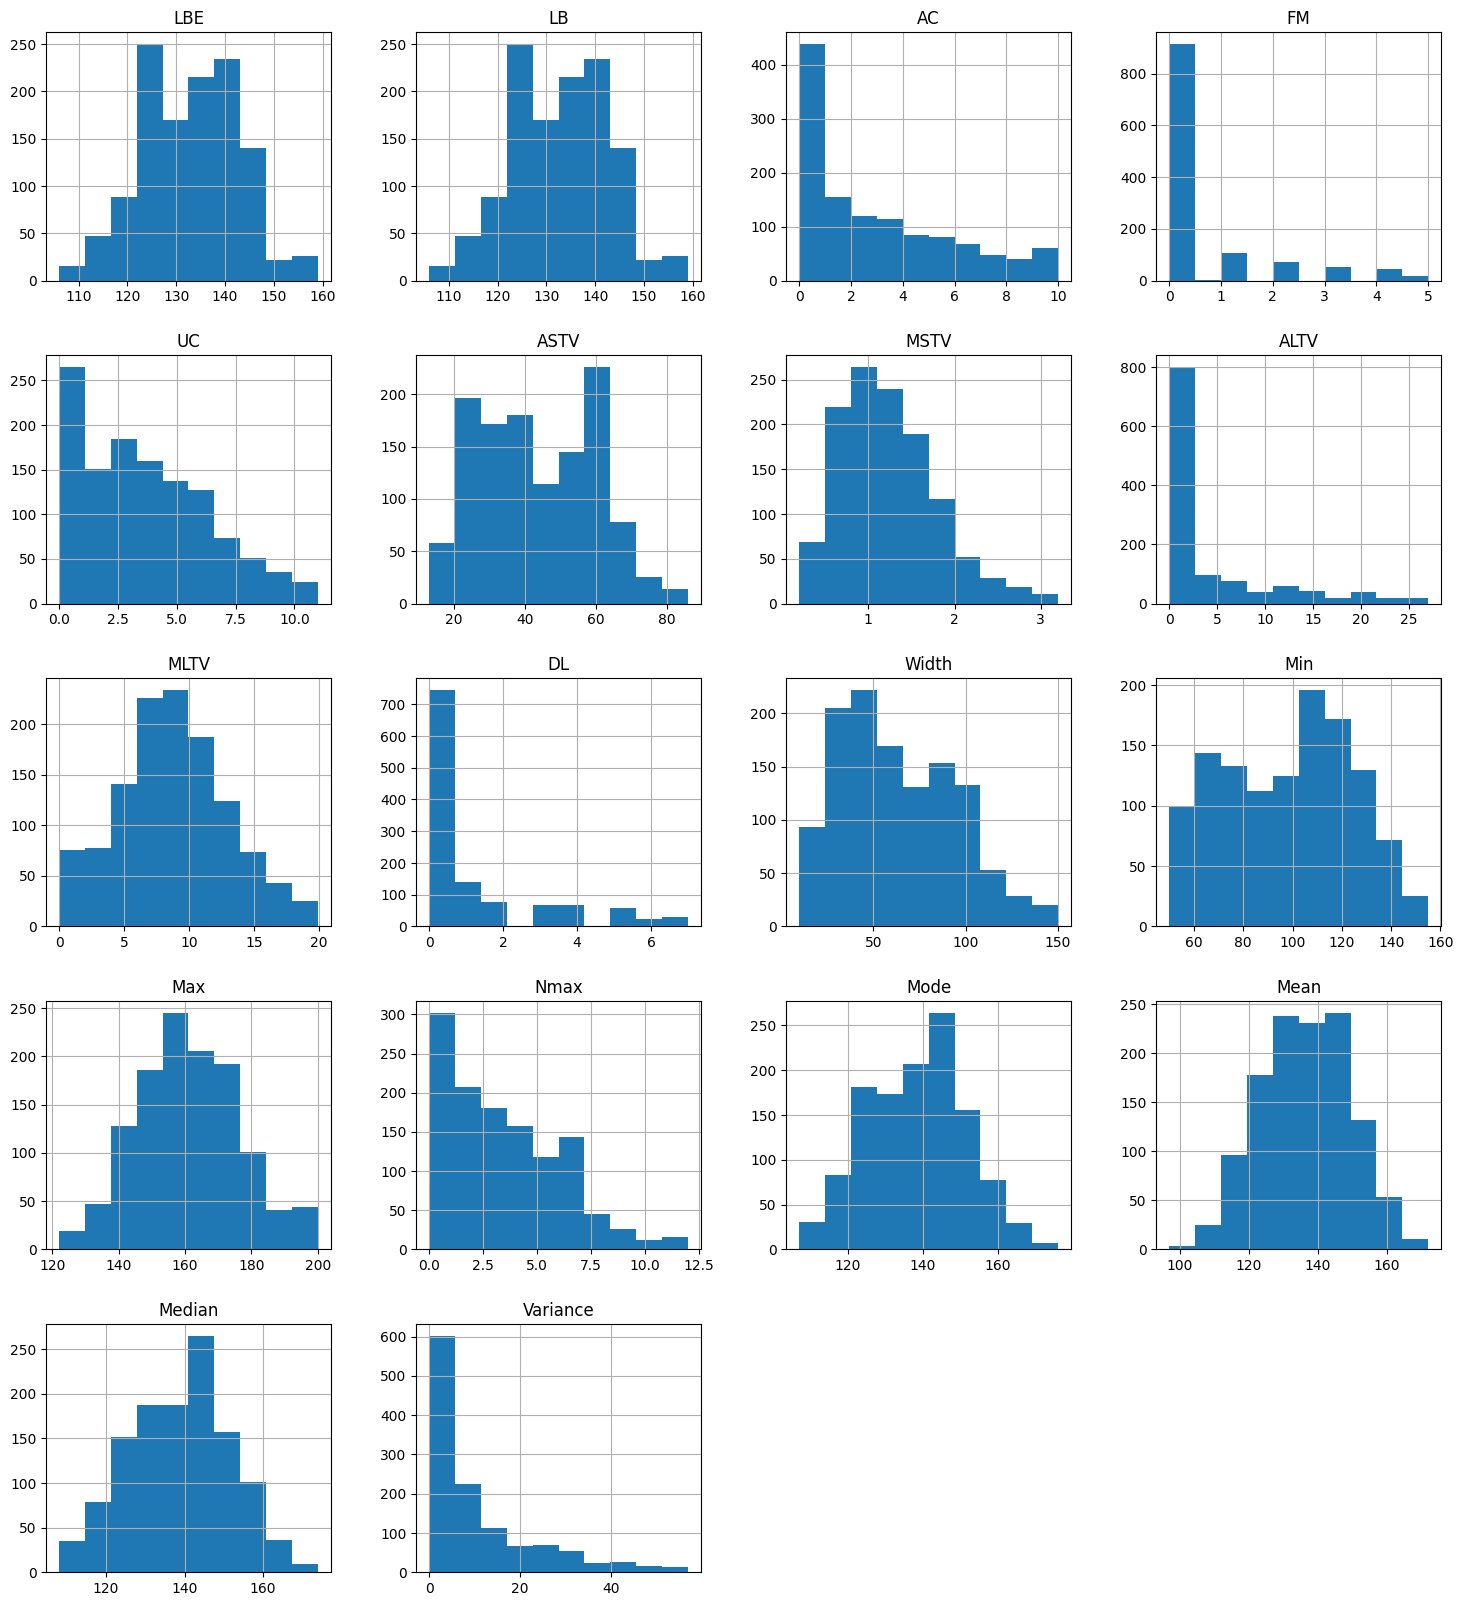

In [15]:
#Imputación de Outliers con método IQR
Q1 = df[varc].quantile(0.25)
Q3 = df[varc].quantile(0.75)

IQR = Q3 - Q1 
mask_iqr = ~((df[varc] < (Q1 - 1.5 * IQR)) | (df[varc] > (Q3 + 1.5 * IQR))).any(axis=1)

df[varc] = df[varc][mask_iqr]
df[varc].hist(figsize=(18,20))


## Visualizaciones

### Histogramas

#### Con KDE (Kernel Density Estimation)

In [16]:
# Histogramas con línea de densidad KDE superpuesta (automática)
plot_histogram(df[varc])

#### Histogramas por grupo

In [17]:
plot_histogram(df[vard], color_by='NSP')

### Gráficos de barras

In [18]:
plot_barplot(df[vard], asc=True)

### Gráficos de caja

In [19]:
#Seleccionamos variables target
target = ['NSP', 'CLASS']

#Graficas de caja por variables target
plot_boxplot(df[varc + target], target=target)

DuplicateError: Expected unique column names, got:
- 'NSP' 2 times

### Gráficos scatter

In [ ]:
from ctg_viz.plots.dotplots import plot_dotplot

# Gráfico de dispersión entre dos variables
plot_dotplot(df, x_col='LB', y_col='AC')

In [41]:
plot_dotplot(df[varc], x_col='LB', y_col='AC', color_by='NSP', size_by='NPS')

Advertencia: La columna 'NSP' no existe. Se ignorará color_by.
Advertencia: La columna 'NPS' no existe. Se ignorará size_by.


In [39]:
df['LB'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2129 entries, 0 to 2128
Series name: LB
Non-Null Count  Dtype  
--------------  -----  
2129 non-null   float64
dtypes: float64(1)
memory usage: 16.8 KB


### Mapa de calor

In [47]:
from ctg_viz.plots.heatmap import plot_heatmap

# Mapa de calor con correlación de Pearson y valores anotados
plot_heatmap(df[varc], method='kendall', annot=True)

### Grafico de Densidad

In [52]:
from ctg_viz.plots.density import plot_density

#gráfico con múltiples clases
plot_density(df, color_by='NSP')